# iTEBD (Infinite Time Evolving Block Decimation) Simulation (GPU accelerated): Ground State + Real Time Quench

iTEBD implementation using PyTorch for ground state search (imaginary time) and quench dynamics (real time). Uses GPU if available.

## Imports and Setup

In [4]:
import torch
import matplotlib.pyplot as plt
import time
import numpy as np # For plotting arrays

## Device Selection

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Simulation Parameters

In [18]:
chi_max = 100
J = 1.0              # Antiferromagnetic
Hx_i = 0.0            # Initial Transverse Field
Hz_i = 0.005            # Initial Longitudinal Field
Hx_f = 2.0            # Final Transverse Field
Hz_f = 0.0           # Final Longitudinal Field
dtau = 0.01             # Imaginary time step (GS)
dt = 0.01           # Real time step (Quench)
NstepsI = 200         # Imaginary time steps
NstepsR = 1000         # Real time steps
CvgCrit = 1.0e-10     # GS Energy convergence
trunc_err_tol = 1e-8  # SVD truncation tolerance
dtype = torch.complex128 # Data type
d = 2                 # Physical dimension

## Operators and Hamiltonian Terms

In [19]:
# Operators
sx = torch.tensor([[0., 1.], [1., 0.]], dtype=dtype, device=device)
sy = torch.tensor([[0., -1j], [1j, 0.]], dtype=dtype, device=device)
sz = torch.tensor([[1., 0.], [0., -1.]], dtype=dtype, device=device)
si = torch.tensor([[1., 0.], [0., 1.]], dtype=dtype, device=device)

# Hamiltonian Terms
H_int = J * torch.kron(sz, sz)
def H_trans(Hx): return -Hx * 0.5 * (torch.kron(sx, si) + torch.kron(si, sx))
def H_long(Hz): return -Hz * 0.5 * (torch.kron(sz, si) + torch.kron(si, sz))

# Initial Hamiltonian & Time Evolution Op (Imaginary)
H_bond_i = H_int + H_trans(Hx_i) + H_long(Hz_i)
H_bond_i_mat = H_bond_i.reshape(d*d, d*d)
U_bond_dtau_mat = torch.linalg.matrix_exp(-dtau * H_bond_i_mat)
U_bond_dtau = U_bond_dtau_mat.reshape(d, d, d, d)
H_bond_i_op = H_bond_i.reshape(d, d, d, d)
print("Initial H and U_dtau created.")

# Final Hamiltonian & Time Evolution Op (Real)
H_bond_f = H_int + H_trans(Hx_f) + H_long(Hz_f)
H_bond_f_mat = H_bond_f.reshape(d*d, d*d)
U_bond_dt_mat = torch.linalg.matrix_exp(-1j * dt * H_bond_f_mat)
U_bond_dt = U_bond_dt_mat.reshape(d, d, d, d)
H_bond_f_op = H_bond_f.reshape(d, d, d, d)
print("Final H and U_dt created.")

Initial H and U_dtau created.
Final H and U_dt created.


## Function: `svd_truncate`

Performs SVD on a reshaped tensor `theta` and truncates based on `chi_max` and `tol`. Returns updated tensors `A_prime`, `B_prime`, new Schmidt values `lambda_new`, and truncation error `trunc_err`.

In [20]:
def svd_truncate(theta, chi_max, tol=1e-12):
    chi_l, d1, d2, chi_r = theta.shape
    theta_matrix = theta.permute(0, 1, 2, 3).reshape(chi_l * d1, d2 * chi_r)
    try:
        U, S, Vh = torch.linalg.svd(theta_matrix, full_matrices=False)
    except torch._C._LinAlgError:
        print("SVD Warning: Did not converge. Adding noise.")
        noise = torch.rand(*theta_matrix.shape, dtype=dtype, device=device) * 1e-10
        U, S, Vh = torch.linalg.svd(theta_matrix + noise, full_matrices=False)
    #threshold = tol * (S[0] if len(S) > 0 and S[0] > 1e-16 else tol)
    #indices_above_tol = torch.where(S > threshold)[0]
    #chi_new = 1 if len(indices_above_tol) == 0 else min(indices_above_tol[-1].item() + 1, chi_max)
    for chi in reversed(range(len(S))):
        if torch.norm(S[chi:]) > tol:
            chi_new = chi + 2
            break
        else:
            pass
    #indices_above_tol = torch.where(S < threshold)[0]
    #chi_new = 1 if len(indices_above_tol) == 0 else min(indices_above_tol[0].item(), chi_max)
    chi_new = min(chi_new, chi_max)
    norm_S_sq = torch.sum(S**2)
    trunc_err = torch.sqrt(torch.sum(S[chi_new:]**2) / norm_S_sq) if norm_S_sq > 1e-16 else 0.0 # truncation error is defined as the norm of the truncated singular values
    S_trunc = S[:chi_new]
    U_trunc = U[:, :chi_new]
    Vh_trunc = Vh[:chi_new, :]
    norm = torch.linalg.norm(S_trunc) if len(S_trunc) > 0 else 0.0
    lambda_new = (S_trunc / norm).to(dtype) if norm > 1e-16 else torch.zeros_like(S_trunc, dtype=dtype, device=device)
    A_prime = U_trunc.reshape(chi_l, d1, -1)
    B_prime_scaled = (Vh_trunc / norm).to(dtype) if norm > 1e-16 else Vh_trunc.to(dtype)
    B_prime = B_prime_scaled.reshape(-1, d2, chi_r)
    return A_prime, lambda_new, B_prime, trunc_err.item()

## Function: `itebd_step`

Performs one iTEBD update step on the A-B bond. Constructs `theta`, applies `U_bond`, performs SVD (`svd_truncate`), and applies gauge transformation. Returns updated `A_new`, `B_new`, `la_new`, and `trunc_err`.

In [21]:
def itebd_step(A, B, la, lb, U_bond, chi_max, tol=1e-12):
    la_stable = la + 1e-16
    lb_stable = lb + 1e-16
    theta = torch.tensordot(A, torch.diag(la_stable), dims=([-1], [0]))
    theta = torch.tensordot(theta, B, dims=([-1], [0]))
    theta = torch.tensordot(torch.diag(lb_stable), theta, dims=([1], [0]))
    theta = torch.tensordot(theta, torch.diag(lb_stable), dims=([-1], [0]))
    theta_evolved = torch.tensordot(U_bond, theta, dims=([2, 3], [1, 2]))
    theta_evolved = theta_evolved.permute(2, 0, 1, 3)
    A_prime, la_new, B_prime, trunc_err = svd_truncate(theta_evolved, chi_max, tol)
    lb_inv = 1.0 / lb_stable
    A_new = torch.tensordot(torch.diag(lb_inv), A_prime, dims=([-1], [0]))
    B_new = torch.tensordot(B_prime, torch.diag(lb_inv), dims=([-1], [0]))
    return A_new, B_new, la_new, trunc_err

## Function: `calculate_energy`

Calculates the energy expectation value per site for the A-B bond using the two-site tensor `theta = A*la*B` and the Hamiltonian `H_bond_op`. Returns the energy (float).

In [22]:
def calculate_energy(A, B, la, lb, H_bond_op):
    """Calculates the energy expectation value <H> for a two-site unit cell using PyTorch."""
    # Use user's version from quench script (modified slightly)
    la = la + 1e-16
    lb = lb + 1e-16 # Not used in this calculation as per user code

    theta = torch.tensordot(A, torch.diag(la), dims=([-1], [0]))
    theta = torch.tensordot(theta, B, dims=([-1], [0])) # (chi_lb, d, d, chi_lb)
    theta = torch.tensordot(torch.diag(lb), theta, dims=([-1], [0])) # (chi_lb, d, d, chi_lb)
    theta = torch.tensordot(theta, torch.diag(lb), dims=([-1], [0])) # (chi_lb, d, d, chi_lb)

    H_theta = torch.tensordot(H_bond_op, theta, dims=([2, 3], [1, 2])) # (d,d,chi_lb,chi_lb)
    H_theta = H_theta.permute(2, 0, 1, 3) # (chi_lb, d, d, chi_lb)

    theta_conj = torch.conj(theta)
    # Using einsum for complex inner product
    energy_numerator = torch.einsum('abcd,abcd->', theta_conj, H_theta)
    norm_sq = torch.einsum('abcd,abcd->', theta_conj, theta)

    energy = (energy_numerator / norm_sq).real if abs(norm_sq) > 1e-15 else float('inf')
    return energy.item() # Return as float

## Function: `calculate_observables`

Calculates the expectation value of a single-site operator `op`, averaged over sites A and B, using the two-site `theta` tensor approach. Returns the average value (float).

In [23]:
def calculate_observables(A, B, la, lb, op):
    la_stable = la + 1e-16
    lb_stable = lb + 1e-16

    # 1. Construct theta = lb * A * la
    # Indices: (chi_lb_left, phys_A, chi_la_right)
    theta = torch.tensordot(A, torch.diag(la_stable), dims=([-1], [0])) # (chi_lb, d, chi_la)
    theta = torch.tensordot(theta, torch.diag(lb_stable), dims=([0], [-1])) # (chi_lb, d, chi_lb)
    theta = theta.permute(2, 0, 1)
    theta_conj = torch.conj(theta)
    norm_sq = torch.einsum('abc,abc->', theta_conj, theta)

    # Avoid division by zero if norm is too small
    if abs(norm_sq) < 1e-15:
        print("Warning: Norm squared is close to zero in calculate_observables.")
        return 0.0

    # 2. Calculate observable
    # Construct theta_opA = op * theta
    theta_opA = torch.tensordot(op, theta, dims=([1],[1]))
    theta_opA = theta_opA.permute(1, 0, 2)
    # Numerator_A = <theta | theta_opA>
    num_A = torch.einsum('abc,abc->', theta_conj, theta_opA) #
    obs_A = (num_A / norm_sq).real

    # 3. Construct theta =la * B * lb
    # Indices: (chi_la_left, phys_B, chi_lb_right)
    theta = torch.tensordot(B, torch.diag(lb_stable), dims=([-1], [0])) # (chi_lb, d, chi_la)
    theta = torch.tensordot(torch.diag(la_stable), theta, dims=([-1], [0])) # (chi_lb, d, chi_la)
    theta = theta.permute(0, 1, 2)
    theta_conj = torch.conj(theta)
    norm_sq = torch.einsum('abc,abc->', theta_conj, theta)

    # Avoid division by zero if norm is too small
    if abs(norm_sq) < 1e-15:
        print("Warning: Norm squared is close to zero in calculate_observables.")
        return 0.0

    # 4. Calculate observable
    # Construct theta_opB = op * theta
    theta_opB = torch.tensordot(op, theta, dims=([1],[1]))
    theta_opB = theta_opB.permute(1, 0, 2)
    # Numerator_B = <theta | theta_opB>
    num_B = torch.einsum('abc,abc->', theta_conj, theta_opB) #
    obs_B = (num_B / norm_sq).real
    obs = (obs_A + obs_B) / 2

    return obs


## Function: `calculate_entropy`

Calculates the Von Neumann entanglement entropy `S = - sum(la_i^2 * log(la_i^2))` from Schmidt values `la`. Returns entropy (float).

In [12]:
def calculate_entropy(la):
    la_sq = la.real**2
    la_sq_clean = la_sq[la_sq > 1e-16]
    if len(la_sq_clean) == 0:
        return 0.0
    entropy = -torch.sum(la_sq_clean * torch.log(la_sq_clean))
    return entropy.item()

## Initialize MPS

In [24]:
chi_init = 1
A = torch.rand(chi_init, d, chi_init, dtype=dtype, device=device)
B = torch.rand(chi_init, d, chi_init, dtype=dtype, device=device)
A /= torch.linalg.norm(A); B /= torch.linalg.norm(B)
la = torch.ones(chi_init, dtype=dtype, device=device) / torch.sqrt(torch.tensor(chi_init, dtype=torch.float64, device=device))
lb = torch.ones(chi_init, dtype=dtype, device=device) / torch.sqrt(torch.tensor(chi_init, dtype=torch.float64, device=device))
la = la.to(dtype); lb = lb.to(dtype)

## Imaginary Time Evolution (Ground State Search)

In [25]:
print("\n--- Starting Imaginary Time Evolution (Ground State Search) ---")
E_last = float('inf')
energies = []
t_start_imag = time.time()

for step in range(NstepsI):
    # A-B update
    A, B, la, trunc_err_A = itebd_step(A, B, la, lb, U_bond_dtau, chi_max, tol=CvgCrit/10)
    # B-A update
    B, A, lb, trunc_err_B = itebd_step(B, A, lb, la, U_bond_dtau, chi_max, tol=CvgCrit/10)

    if (step + 1) % 10 == 0:
        E_bond_AB = calculate_energy(A, B, la, lb, H_bond_i_op)
        E_bond_BA = calculate_energy(B, A, lb, la, H_bond_i_op)
        E_curr = (E_bond_AB + E_bond_BA) / 2.0
        energies.append(E_curr)
        delta_E = abs(E_curr - E_last)
        print(f"Im Step {(step+1):<4}/{NstepsI}, E={E_curr:.10f}, dE={delta_E:.2e}, "
              f"TrA={trunc_err_A:.2e}, TrB={trunc_err_B:.2e}, Chi=({len(la)},{len(lb)})")
        if delta_E < CvgCrit:
            print(f"Converged at step {step + 1}")
            break
        E_last = E_curr

t_end_imag = time.time()
print(f"Imaginary time evolution took {t_end_imag - t_start_imag:.2f} seconds.")

A_gs = A.clone(); B_gs = B.clone(); la_gs = la.clone(); lb_gs = lb.clone()
if energies:
    print(f"Ground state energy: {energies[-1]:.12f}")
else:
     print("Ground state energy not calculated.")


--- Starting Imaginary Time Evolution (Ground State Search) ---
Im Step 10  /200, E=-0.3204394200, dE=inf, TrA=5.92e-19, TrB=8.00e-18, Chi=(3,3)
Im Step 20  /200, E=-0.5378112994, dE=2.17e-01, TrA=1.13e-18, TrB=1.83e-17, Chi=(3,3)
Im Step 30  /200, E=-0.7177203202, dE=1.80e-01, TrA=1.22e-18, TrB=2.37e-17, Chi=(3,3)
Im Step 40  /200, E=-0.8451556728, dE=1.27e-01, TrA=4.94e-19, TrB=1.35e-17, Chi=(3,3)
Im Step 50  /200, E=-0.9220488525, dE=7.69e-02, TrA=2.15e-20, TrB=1.31e-17, Chi=(3,3)
Im Step 60  /200, E=-0.9628700803, dE=4.08e-02, TrA=3.13e-20, TrB=1.00e-17, Chi=(3,3)
Im Step 70  /200, E=-0.9828425530, dE=2.00e-02, TrA=8.84e-21, TrB=5.94e-18, Chi=(3,3)
Im Step 80  /200, E=-0.9921902278, dE=9.35e-03, TrA=1.02e-21, TrB=3.62e-18, Chi=(3,3)
Im Step 90  /200, E=-0.9964702746, dE=4.28e-03, TrA=1.60e-21, TrB=2.38e-18, Chi=(3,3)
Im Step 100 /200, E=-0.9984098874, dE=1.94e-03, TrA=2.61e-22, TrB=1.03e-18, Chi=(3,3)
Im Step 110 /200, E=-0.9992847251, dE=8.75e-04, TrA=2.65e-22, TrB=5.64e-19, Chi=

## Real Time Evolution (Quench)

In [ ]:
print("\n--- Starting Real Time Evolution ---")
A = A_gs.clone(); B = B_gs.clone(); la = la_gs.clone(); lb = lb_gs.clone()

# Storage for plotting (transfer to CPU and convert to numpy)
times_np = np.arange(NstepsR + 1) * dt
Mx_t_np = np.zeros(NstepsR + 1)
Mz_t_np = np.zeros(NstepsR + 1)
Entropy_t_np = np.zeros(NstepsR + 1)
trunc_errors_A_rt_np = np.zeros(NstepsR)
trunc_errors_B_rt_np = np.zeros(NstepsR)
bond_dims_la_rt_np = np.zeros(NstepsR, dtype=int)
bond_dims_lb_rt_np = np.zeros(NstepsR, dtype=int)

# Initial observables
Mx_t_np[0] = calculate_observables(A, B, la, lb, sx)
Mz_t_np[0] = calculate_observables(A, B, la, lb, sz)
Entropy_t_np[0] = calculate_entropy(la)

t_start_real = time.time()
for step in range(NstepsR):
    # A-B update
    A, B, la, trunc_err_A = itebd_step(A, B, la, lb, U_bond_dt, chi_max, tol=trunc_err_tol)
    trunc_errors_A_rt_np[step] = trunc_err_A
    bond_dims_la_rt_np[step] = len(la)

    # B-A update
    B, A, lb, trunc_err_B = itebd_step(B, A, lb, la, U_bond_dt, chi_max, tol=trunc_err_tol)
    trunc_errors_B_rt_np[step] = trunc_err_B
    bond_dims_lb_rt_np[step] = len(lb)

    # Calculate observables
    Mx_t_np[step + 1] = calculate_observables(A, B, la, lb, sx)
    Mz_t_np[step + 1] = calculate_observables(A, B, la, lb, sz)
    Entropy_t_np[step + 1] = calculate_entropy(la) # Use entropy of A-B bond

    if (step + 1) % 20 == 0:
        print(f"RT Step {(step+1):<4}/{NstepsR}, t={times_np[step+1]:.2f}, "
              f"Mx={Mx_t_np[step+1]:.4f}, Mz={Mz_t_np[step+1]:.4f}, S={Entropy_t_np[step+1]:.4f}, "
              f"Trunc_A={trunc_err_A:.1e}, Trunc_B={trunc_err_B:.1e}, Chi=({len(la)},{len(lb)})")

t_end_real = time.time()
print(f"Real time evolution took {t_end_real - t_start_real:.2f} seconds.")


--- Starting Real Time Evolution ---
RT Step 20  /1000, t=0.20, Mx=0.2446, Mz=0.0000, S=0.0096, TrA=2.9e-11, TrB=3.8e-11, Chi=(7,7)
RT Step 40  /1000, t=0.40, Mx=0.4269, Mz=0.0000, S=0.1495, TrA=7.6e-12, TrB=1.0e-11, Chi=(11,11)
RT Step 60  /1000, t=0.60, Mx=0.2639, Mz=-0.0000, S=0.3468, TrA=3.3e-10, TrB=3.7e-10, Chi=(13,13)
RT Step 80  /1000, t=0.80, Mx=0.2130, Mz=-0.0000, S=0.4320, TrA=1.8e-09, TrB=1.1e-09, Chi=(16,17)
RT Step 100 /1000, t=1.00, Mx=0.2380, Mz=-0.0000, S=0.5230, TrA=2.1e-09, TrB=2.3e-09, Chi=(21,21)
RT Step 120 /1000, t=1.20, Mx=0.2161, Mz=0.0000, S=0.6405, TrA=9.6e-10, TrB=1.0e-09, Chi=(28,28)
RT Step 140 /1000, t=1.40, Mx=0.2522, Mz=0.0000, S=0.7551, TrA=2.3e-09, TrB=2.5e-09, Chi=(33,33)
RT Step 160 /1000, t=1.60, Mx=0.2653, Mz=0.0000, S=0.9000, TrA=4.4e-09, TrB=4.8e-09, Chi=(42,42)
RT Step 180 /1000, t=1.80, Mx=0.2568, Mz=-0.0000, S=1.0395, TrA=3.4e-09, TrB=4.3e-09, Chi=(51,50)
RT Step 200 /1000, t=2.00, Mx=0.2658, Mz=-0.0000, S=1.1679, TrA=6.5e-09, TrB=6.0e-09, C

## Compare with exact solution

Time =  0.0
transverse magnetization =  0.0
Time =  1.0
transverse magnetization =  0.23762042756099921
Time =  2.0
transverse magnetization =  0.265497550488879
Time =  3.0
transverse magnetization =  0.2531998928371433
Time =  4.0
transverse magnetization =  0.24658460964660556
Time =  5.0
transverse magnetization =  0.25218006149063577
Time =  6.0
transverse magnetization =  0.24787456368549554
Time =  7.0
transverse magnetization =  0.24805025306000106
Time =  8.0
transverse magnetization =  0.25076651571723585
Time =  9.0
transverse magnetization =  0.24864164589937787
Time =  10.0
transverse magnetization =  0.2502012533507687
Total computing time =  0.691570312001204


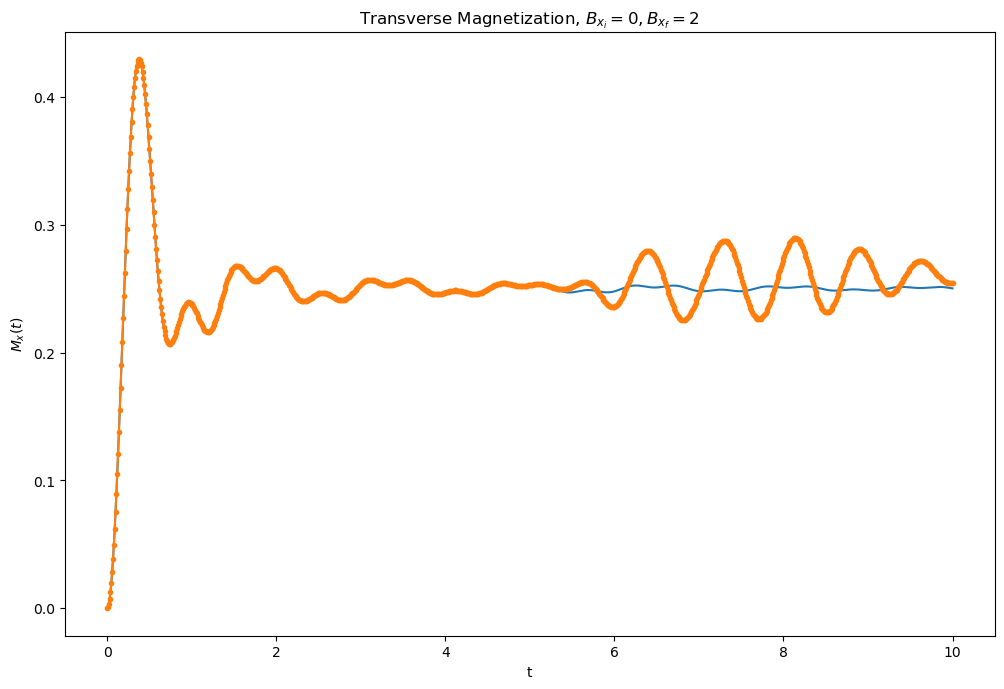

In [27]:
import os
import copy
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import ode
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy import integrate
from scipy.special import hermite
from tqdm import tqdm
from mpmath import laguerre
from mpmath import hyperu
from mpmath import pcfd
import timeit

## linear quench analytic
## parameter setting
global J, hi, hf, k, quenchtime
hi = 0  # initial transverse field
hf = 2  # final transverse field
quenchtime = 0

J = 1;
# vmax = 2 * J * min(1,hf); # 2 * J * min(1,hf) / 2

dt = 1e-2;
tend = 10/(1); # match for vmax*t
step = int(np.ceil(tend/dt));
t_analytic = np.arange(0,step+1,1) * dt;

N = 1000
eps = 1e-5
n = np.arange(- N / 2, N/2-1+eps)
if N % 2 == 0: # even sector : Neveu-Schwarz(NS) sector
    k = 2*np.pi/N * (n+1/2)
    pstep = N;
    prange = 2 * np.pi;
    dk = prange / pstep;

else: # odd sector : Ramond(R) sector
    k = 2*np.pi/N * n
    pstep = N;
    prange = 2 * np.pi;
    dk = prange / pstep;

#k = np.linspace(-prange/2, prange/2, pstep+1);

# the diagonalization condition, which the initial condition is exp(i*theta_k) = (g - exp(i*k)) / sqrt(1+g^2-2*g*cosk)
theta_k = - 1j * np.log((hi - np.exp(1j*k)) / np.sqrt(1+hi**2 - 2*hi*np.cos(k)))
theta_minus_k = - 1j * np.log((hi - np.exp(1j*(-k))) / np.sqrt(1+hi**2 - 2*hi*np.cos(-k)))
theta_k = np.real(theta_k)
theta_minus_k = np.real(theta_minus_k)
uki = np.cos(theta_k/2)
v_minus_ki = np.sin(theta_minus_k/2)
v_conj_minus_ki = np.conj(v_minus_ki) # initial condition
uki_dif = - 1j * 2 * J * (hi - np.cos(k)) * uki - 1j * 2 * J * np.sin(k) * v_minus_ki
v_conj_minus_ki_dif = - 1j * 2 * J * np.sin(k) * uki + 1j * 2 * J * (hi - np.cos(k)) * v_minus_ki


## after the quench, the equations for the bogoliubov coefficients simplify to d^2/dt^2(y_k(t)) + epsilon_k(g_f)^2 * y_k(t) = 0
def TM_function_post_quench(t, uk0, v_conj_minus_k0):
    global J, hi, hf, k
    A_k = 2 * J * (hf - np.cos(k))
    B_k = 2 * J * np.sin(k)
    E_k = np.sqrt((A_k)**2 + (B_k)**2)
    # y_k = c3_y*exp(i*E_k*t) + c4_y*exp(-i*E_k*t)
    c3_u = np.exp(-1j*E_k*quenchtime) / (2*E_k) * ((E_k-A_k)*uk0 - B_k*(v_conj_minus_k0))
    c4_u = np.exp(1j*E_k*quenchtime) / (2*E_k) * ((E_k+A_k)*uk0 + B_k*(v_conj_minus_k0))
    c3_v = np.exp(-1j*E_k*quenchtime) / (2*E_k) * ((E_k+A_k)*(v_conj_minus_k0) - B_k*uk0)
    c4_v = np.exp(1j*E_k*quenchtime) / (2*E_k) * ((E_k-A_k)*(v_conj_minus_k0) + B_k*uk0)
    uk = c3_u * np.exp(1j*E_k*t) + c4_u * np.exp(-1j*E_k*t)
    v_conj_minus_k = c3_v * np.exp(1j*E_k*t) + c4_v * np.exp(-1j*E_k*t)
    return uk, v_conj_minus_k


## numerical integration
transverse_magnetization_t_analytic = np.zeros(len(t_analytic))
transverse_magnetization_instant_t = ( - np.real(1j  / np.pi * dk * ((uki[0]*(v_minus_ki[0])+uki[-1]*(v_minus_ki[-1])) + np.sum(uki[1:-1]*(v_minus_ki[1:-1])))) + 1 / np.pi * dk * ((abs((uki[0]))**2+abs((uki[-1]))**2) + np.sum(abs((uki[1:-1]))**2)) - 1 ) # without divide by 2 for first and last element of function (yet sum over all elements of function) # since it's integrate in a 2*pi circle, nothing overlap
transverse_magnetization_t_analytic[0] = transverse_magnetization_instant_t
print('Time = ', t_analytic[0])
print('transverse magnetization = ', transverse_magnetization_instant_t)

start = timeit.default_timer()
for i in range(1, step+1):
    ukn, v_conj_minus_kn = TM_function_post_quench(t_analytic[i], uki,  v_conj_minus_ki);
    v_minus_kn = np.conj(v_conj_minus_kn)
    transverse_magnetization_instant_t =  ( - np.real(1j  / np.pi * dk * ((ukn[0]*(v_minus_kn[0])+ukn[-1]*(v_minus_kn[-1])) + np.sum(ukn[1:-1]*(v_minus_kn[1:-1])))) + 1 / np.pi * dk * ((abs((ukn[0]))**2+abs((ukn[-1]))**2) + np.sum(abs((ukn[1:-1]))**2)) - 1 )
    transverse_magnetization_t_analytic[i] = transverse_magnetization_instant_t;


    if t_analytic[i] % 1 == 0:
        print('Time = ', t_analytic[i])
        print('transverse magnetization = ', transverse_magnetization_instant_t)

end = timeit.default_timer()
print('Total computing time = ', end-start)

#transverse_magnetization_t_rk4_linear_k100 = transverse_magnetization_t_rk4_linear
# fprintf('transverse magnetization = %d\n', transverse_magnetization_t)
plt.figure(dpi=100,figsize=(12,8))
plt.plot((1)*t_analytic,transverse_magnetization_t_analytic,'-');
plt.plot(times_np, Mx_t_np, 'o-', markersize=3, label=r'$\langle S_x \rangle$')
plt.title(r'Transverse Magnetization, ' + r'$B_{x_{i}} = $' + str(hi) + '$, B_{x_{f}} = $' + str(hf));
plt.xlabel('t');
plt.ylabel(r'$M_x(t)$');
plt.show()


## Plotting Results

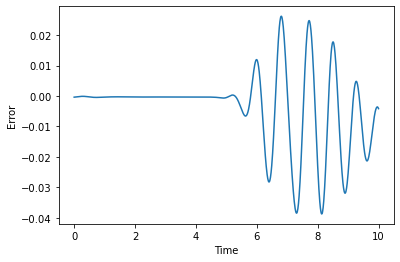

In [36]:
plt.plot(times_np[:], transverse_magnetization_t_analytic-Mx_t_np)
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

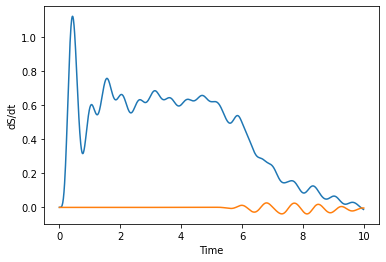

In [ ]:
plt.plot(times_np[:-1], np.diff(Entropy_t_np)/dt)
plt.xlabel("Time")
plt.ylabel("dS/dt")
plt.show()


Plotting real-time evolution results...


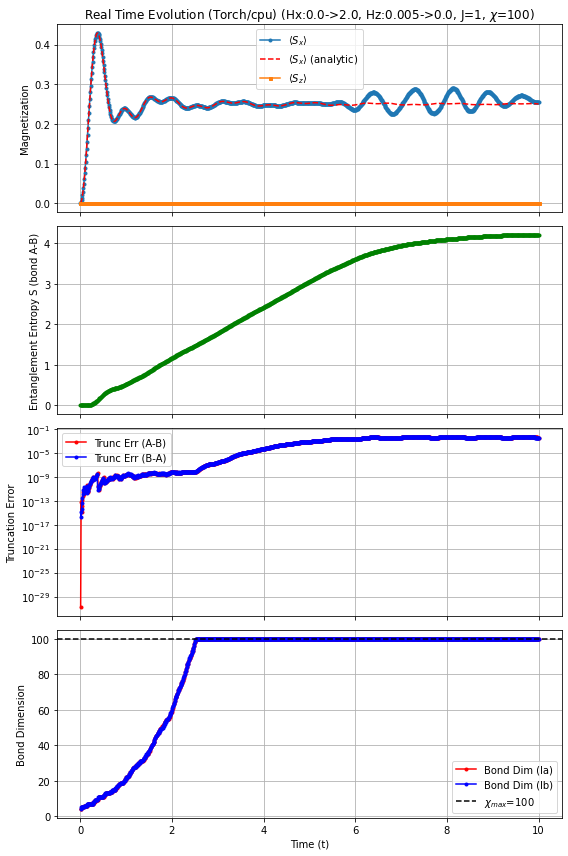


Full simulation complete.


In [28]:
print("\nPlotting real-time evolution results...")
fig_rt, axs_rt = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axs_rt[0].plot(times_np, Mx_t_np, 'o-', markersize=3, label=r'$\langle S_x \rangle$')
axs_rt[0].plot(times_np, transverse_magnetization_t_analytic, 'r--', markersize=3, label=r'$\langle S_x \rangle$ (analytic)')
axs_rt[0].plot(times_np, Mz_t_np, 's-', markersize=3, label=r'$\langle S_z \rangle$')

axs_rt[0].set_ylabel("Magnetization")
axs_rt[0].set_title(f"Real Time Evolution (Torch/{device}) (Hx:{Hx_i}->{Hx_f}, Hz:{Hz_i}->{Hz_f}, J={J}, $\chi$={chi_max})")
axs_rt[0].legend(); axs_rt[0].grid(True)

axs_rt[1].plot(times_np, Entropy_t_np, 'o-', markersize=3, color='g')
axs_rt[1].set_ylabel("Entanglement Entropy S (bond A-B)")
axs_rt[1].grid(True)

axs_rt[2].plot(times_np[1:], trunc_errors_A_rt_np, 'r.-', label='Trunc Err (A-B)')
axs_rt[2].plot(times_np[1:], trunc_errors_B_rt_np, 'b.-', label='Trunc Err (B-A)')
axs_rt[2].set_ylabel("Truncation Error"); axs_rt[2].set_yscale('log'); axs_rt[2].legend(); axs_rt[2].grid(True)

axs_rt[3].plot(times_np[1:], bond_dims_la_rt_np, 'r.-', label='Bond Dim (la)')
axs_rt[3].plot(times_np[1:], bond_dims_lb_rt_np, 'b.-', label='Bond Dim (lb)')
axs_rt[3].set_ylabel("Bond Dimension"); axs_rt[3].set_xlabel("Time (t)")
axs_rt[3].axhline(chi_max, color='k', linestyle='--', label=f'$\chi_{{max}}$={chi_max}')
axs_rt[3].legend(); axs_rt[3].grid(True)

plt.tight_layout()
plt.show()

print("\nFull simulation complete.")